# Team Analysis
This notebook analyzes team-level performance from standings data and visualizes key patterns for offense, defense, and home-road splits.

In [12]:
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

## Setup: Data Load and Database
Load processed standings data, write it to SQLite, and verify the standings table is queryable.

In [13]:
# Load cleaned standings produced in notebook 01
df_standings = pd.read_csv('../data/processed/standings_clean.csv')
print(df_standings.shape)
df_standings.head()

# Connect to our SQLite database (creates it if it doesn't exist)
# Persist standings snapshot for SQL-based analysis in this notebook
conn = sqlite3.connect('../database/nhl.db')

# Write standings to the database
df_standings.to_sql('standings', conn, if_exists='replace', index=False)

print("Standings table written to database!")

# Verify it worked by querying it back with SQL
query = """
    SELECT team_name, team_abbrev, points, wins, losses, goalFor, goalAgainst
    FROM standings
    ORDER BY points DESC
    LIMIT 5
"""

pd.read_sql_query(query, conn)

(32, 79)
Standings table written to database!


,team_name,team_abbrev,points,wins,losses,goalFor,goalAgainst
0,Avalanche,COL,121,55,16,302,203
1,Hurricanes,CAR,113,53,22,296,240
2,Stars,DAL,112,50,20,279,226
3,Sabres,BUF,109,50,23,288,241
4,Lightning,TBL,106,50,26,290,231


## Section 1: Standings Overview
Question: Which teams are leading the league, and by how much based on points and goal differential?
This section ranks teams by points and compares conference/division context with goal differential.

In [14]:

# Let's look at the full standings sorted by points
query = """
    SELECT team_name, team_abbrev, conferenceName, divisionName,
           points, wins, losses, otLosses, goalFor, goalAgainst, goalDifferential
    FROM standings
    ORDER BY points DESC
"""

df_ranked = pd.read_sql_query(query, conn)
df_ranked.head(10)

,team_name,team_abbrev,conferenceName,divisionName,points,wins,losses,otLosses,goalFor,goalAgainst,goalDifferential
0,Avalanche,COL,Western,Central,121,55,16,11,302,203,99
1,Hurricanes,CAR,Eastern,Metropolitan,113,53,22,7,296,240,56
2,Stars,DAL,Western,Central,112,50,20,12,279,226,53
3,Sabres,BUF,Eastern,Atlantic,109,50,23,9,288,241,47
4,Lightning,TBL,Eastern,Atlantic,106,50,26,6,290,231,59
5,Canadiens,MTL,Eastern,Atlantic,106,48,24,10,283,256,27
6,Wild,MIN,Western,Central,104,46,24,12,272,240,32
7,Bruins,BOS,Eastern,Atlantic,100,45,27,10,272,250,22
8,Senators,OTT,Eastern,Atlantic,99,44,27,11,278,246,32
9,Penguins,PIT,Eastern,Metropolitan,98,41,25,16,293,268,25


## Section 2: Offense vs Defense Profile
Question: Are teams succeeding more through offensive production or through defensive suppression?
This distinction matters: defensive teams are often more consistent in playoffs, while offensive teams can be more volatile.

In [15]:

query = """
    SELECT team_name, team_abbrev, conferenceName,
           points, goalFor, goalAgainst, goalDifferential,
           ROUND(CAST(goalFor AS FLOAT) / gamesPlayed, 2) as goals_for_per_game,
           ROUND(CAST(goalAgainst AS FLOAT) / gamesPlayed, 2) as goals_against_per_game
    FROM standings
    ORDER BY points DESC
"""

df_offense_defense = pd.read_sql_query(query, conn)
df_offense_defense.head(10)

,team_name,team_abbrev,conferenceName,points,goalFor,goalAgainst,goalDifferential,goals_for_per_game,goals_against_per_game
0,Avalanche,COL,Western,121,302,203,99,3.68,2.48
1,Hurricanes,CAR,Eastern,113,296,240,56,3.61,2.93
2,Stars,DAL,Western,112,279,226,53,3.40,2.76
3,Sabres,BUF,Eastern,109,288,241,47,3.51,2.94
4,Lightning,TBL,Eastern,106,290,231,59,3.54,2.82
5,Canadiens,MTL,Eastern,106,283,256,27,3.45,3.12
6,Wild,MIN,Western,104,272,240,32,3.32,2.93
7,Bruins,BOS,Eastern,100,272,250,22,3.32,3.05
8,Senators,OTT,Eastern,99,278,246,32,3.39,3.00
9,Penguins,PIT,Eastern,98,293,268,25,3.57,3.27


### Visualization: Offense vs Defense Scatter
Question: Which teams combine above-average scoring with below-average goals against?
Each dot represents a team, and league-average lines create quadrants to separate elite, defensive, offensive, and struggling profiles.

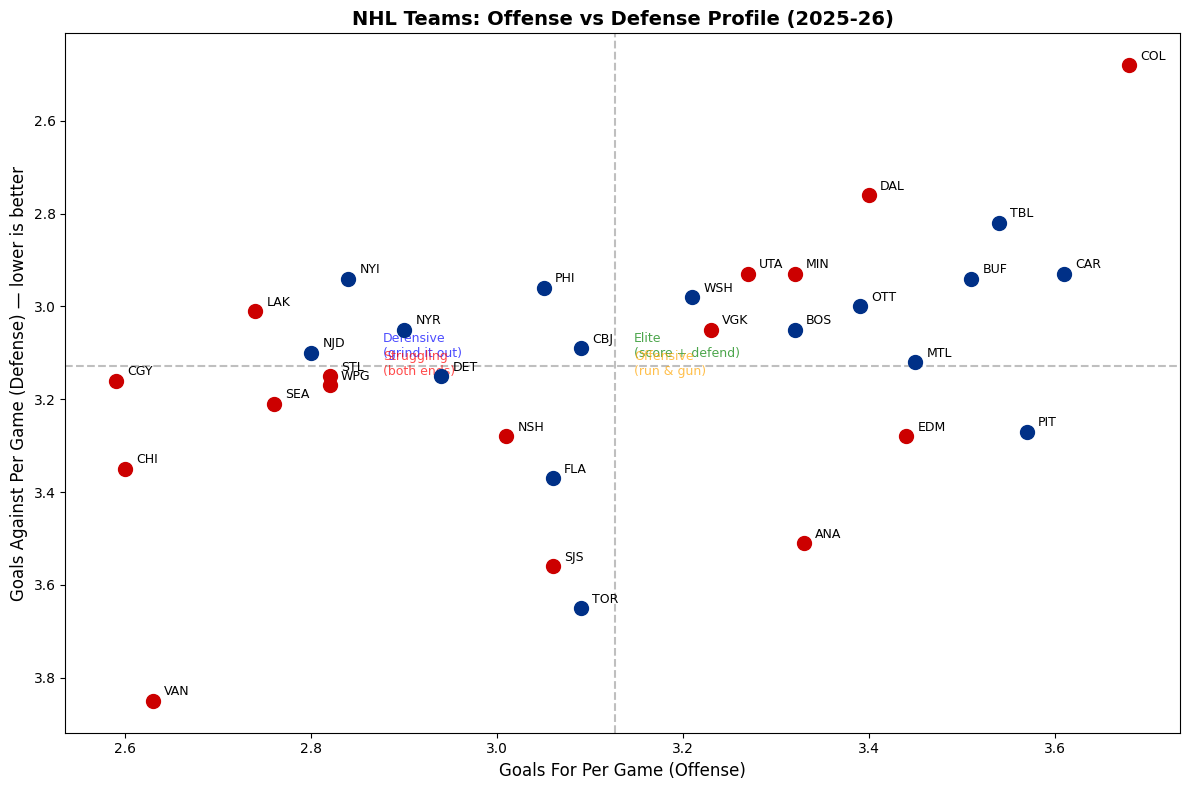

In [16]:

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each team as a dot
for _, row in df_offense_defense.iterrows():
    color = '#003087' if row['conferenceName'] == 'Eastern' else '#CC0000'
    ax.scatter(row['goals_for_per_game'], row['goals_against_per_game'], 
               color=color, s=100, zorder=5)
    ax.annotate(row['team_abbrev'], 
                (row['goals_for_per_game'], row['goals_against_per_game']),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

# League average lines — creates the four quadrants
avg_gf = df_offense_defense['goals_for_per_game'].mean()
avg_ga = df_offense_defense['goals_against_per_game'].mean()
ax.axvline(x=avg_gf, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=avg_ga, color='gray', linestyle='--', alpha=0.5)

# Quadrant labels
ax.text(avg_gf + 0.02, avg_ga - 0.02, 'Elite\n(score + defend)', fontsize=9, color='green', alpha=0.7)
ax.text(avg_gf - 0.25, avg_ga - 0.02, 'Defensive\n(grind it out)', fontsize=9, color='blue', alpha=0.7)
ax.text(avg_gf + 0.02, avg_ga + 0.02, 'Offensive\n(run & gun)', fontsize=9, color='orange', alpha=0.7)
ax.text(avg_gf - 0.25, avg_ga + 0.02, 'Struggling\n(both ends)', fontsize=9, color='red', alpha=0.7)

# Note: y-axis is inverted — lower goals against is BETTER
ax.invert_yaxis()
ax.set_xlabel('Goals For Per Game (Offense)', fontsize=12)
ax.set_ylabel('Goals Against Per Game (Defense) — lower is better', fontsize=12)
ax.set_title('NHL Teams: Offense vs Defense Profile (2025-26)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/02_offense_defense_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3: Home vs Road Performance
Question: Which teams show the largest home-ice advantage versus road performance?
Some teams are fortress-at-home while others travel well; this split is especially relevant for fatigue analysis later in the project.

In [17]:

query = """
    SELECT team_name, team_abbrev,
           homeWins, homeLosses, homeOtLosses,
           roadWins, roadLosses, roadOtLosses,
           ROUND(CAST(homeWins AS FLOAT) / homeGamesPlayed, 3) as home_win_pct,
           ROUND(CAST(roadWins AS FLOAT) / roadGamesPlayed, 3) as road_win_pct
    FROM standings
    ORDER BY points DESC
"""

df_home_road = pd.read_sql_query(query, conn)

# Calculate the split — positive means better at home, negative means better on road
df_home_road['home_road_split'] = (df_home_road['home_win_pct'] - df_home_road['road_win_pct']).round(3)

df_home_road.head(10)

,team_name,team_abbrev,homeWins,homeLosses,homeOtLosses,roadWins,roadLosses,roadOtLosses,home_win_pct,road_win_pct,home_road_split
0,Avalanche,COL,26,9,6,29,7,5,0.634,0.707,-0.073
1,Hurricanes,CAR,29,10,2,24,12,5,0.707,0.585,0.122
2,Stars,DAL,26,11,4,24,9,8,0.634,0.585,0.049
3,Sabres,BUF,26,10,5,24,13,4,0.634,0.585,0.049
4,Lightning,TBL,26,14,1,24,12,5,0.634,0.585,0.049
5,Canadiens,MTL,24,15,2,24,9,8,0.585,0.585,0.000
6,Wild,MIN,23,10,8,23,14,4,0.561,0.561,0.000
7,Bruins,BOS,29,11,1,16,16,9,0.707,0.390,0.317
8,Senators,OTT,23,12,6,21,15,5,0.561,0.512,0.049
9,Penguins,PIT,20,13,8,21,12,8,0.488,0.512,-0.024


### Visualization: Home vs Road Win Rates
Question: How does each team's home win percentage compare directly to its road win percentage?

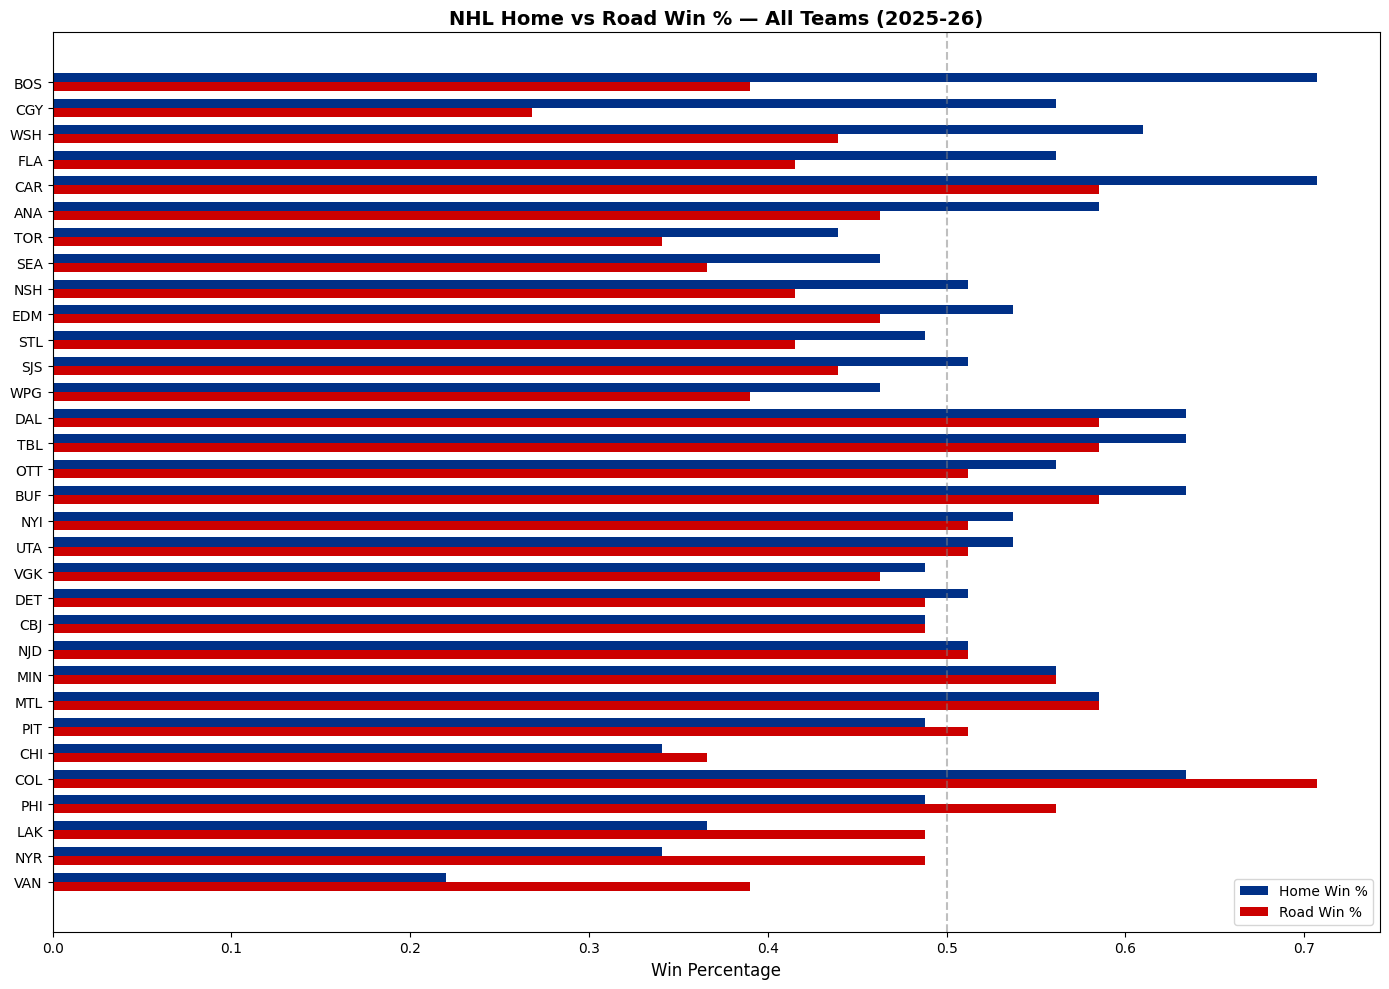

In [18]:
# Improved visualization — grouped bars side by side
fig, ax = plt.subplots(figsize=(14, 10))

bar_width = 0.35
y = range(len(df_home_road_sorted))

home_bars = ax.barh([i + bar_width/2 for i in y], df_home_road_sorted['home_win_pct'], 
                     height=bar_width, label='Home Win %', color='#003087')
road_bars = ax.barh([i - bar_width/2 for i in y], df_home_road_sorted['road_win_pct'], 
                     height=bar_width, label='Road Win %', color='#CC0000')

ax.set_yticks(y)
ax.set_yticklabels(df_home_road_sorted['team_abbrev'])
ax.set_xlabel('Win Percentage', fontsize=12)
ax.set_title('NHL Home vs Road Win % — All Teams (2025-26)', fontsize=14, fontweight='bold')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig('../visuals/03_home_road_splits.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4: Possession Proxy
Question: Which teams appear to control play based on goal-share proxy metrics?
This uses a Corsi-style approximation based on goal share as a directional proxy until full game-level shot attempt data is introduced in notebook 04.

In [19]:
#
#
#

query = """
    SELECT team_name, team_abbrev, conferenceName,
           goalFor, goalAgainst, points,
           ROUND(CAST(goalFor AS FLOAT) / (goalFor + goalAgainst), 3) as possession_proxy,
           ROUND(CAST(goalFor AS FLOAT) / gamesPlayed, 2) as goals_for_per_game,
           ROUND(CAST(goalAgainst AS FLOAT) / gamesPlayed, 2) as goals_against_per_game
    FROM standings
    ORDER BY possession_proxy DESC
"""

df_corsi = pd.read_sql_query(query, conn)
df_corsi.head(10)

,team_name,team_abbrev,conferenceName,goalFor,goalAgainst,points,possession_proxy,goals_for_per_game,goals_against_per_game
0,Avalanche,COL,Western,302,203,121,0.598,3.68,2.48
1,Lightning,TBL,Eastern,290,231,106,0.557,3.54,2.82
2,Hurricanes,CAR,Eastern,296,240,113,0.552,3.61,2.93
3,Stars,DAL,Western,279,226,112,0.552,3.40,2.76
4,Sabres,BUF,Eastern,288,241,109,0.544,3.51,2.94
5,Wild,MIN,Western,272,240,104,0.531,3.32,2.93
6,Senators,OTT,Eastern,278,246,99,0.531,3.39,3.00
7,Mammoth,UTA,Western,268,240,92,0.528,3.27,2.93
8,Canadiens,MTL,Eastern,283,256,106,0.525,3.45,3.12
9,Penguins,PIT,Eastern,293,268,98,0.522,3.57,3.27


### Note on Possession Metrics
This proxy is directional and useful for quick comparisons, but true Corsi/Fenwick requires game-level shot-attempt data for stronger predictive signal.

In [20]:
# Note moved to markdown section above.

SyntaxError: unterminated string literal (detected at line 4) (1007514429.py, line 4)